# **TP2**



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn. linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
from sklearn.datasets import make_classification

# Génération de données plus complexes
X_large, y_large = make_classification(n_samples=3000, n_features=50, n_informative=10, n_redundant=10, random_state=42)
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_large, y_large, test_size=0.3, random_state=42)

print(f'Dimensions du dataset: {X_large.shape}')

Dimensions du dataset: (3000, 50)


In [ ]:
from sklearn.pipeline import Pipeline

# 1. Modèle sans optimisation (penalty='none' ou C très élevé)
model_none = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(penalty=None, solver='lbfgs', max_iter=10000))
])

# 2. Modèle avec optimisation L1 (Lasso)
model_l1_new = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=10000))
])

# 3. Modèle avec optimisation L2 (Ridge)
model_l2_new = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(penalty='l2', solver='lbfgs', C=0.1, max_iter=10000))
])

# Entraînement et évaluation
models = {'Sans Optimisation': model_none, 'L1 (Lasso)': model_l1_new, 'L2 (Ridge)': model_l2_new}

for name, m in models.items():
    m.fit(X_train_l, y_train_l)
    acc = m.score(X_test_l, y_test_l)
    print(f'{name} Accuracy: {acc:.4f}')

Sans Optimisation Accuracy: 0.8333
L1 (Lasso) Accuracy: 0.8367
L2 (Ridge) Accuracy: 0.8333


Nombre de coefficients à zéro (L1): 24
Nombre de coefficients à zéro (L2): 0


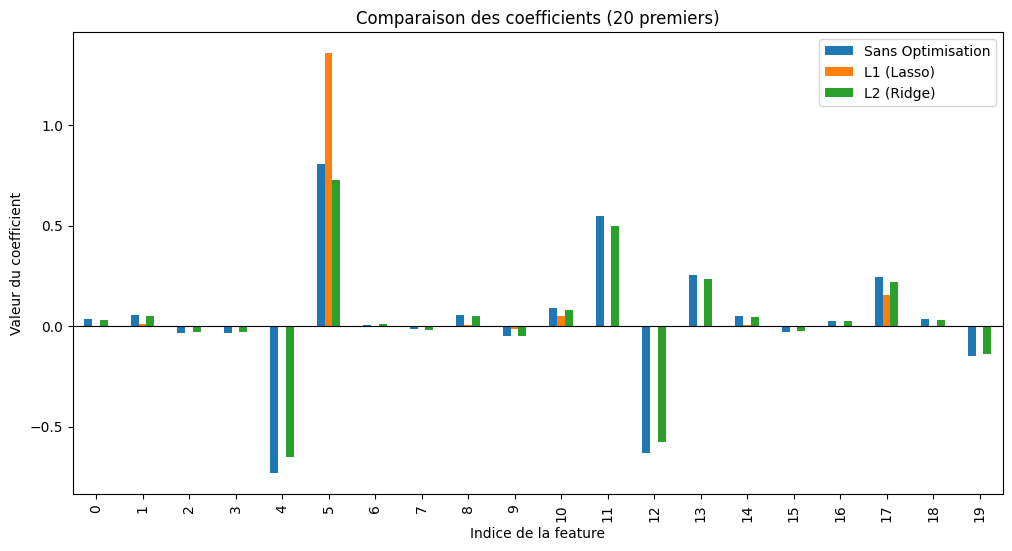

In [ ]:
import pandas as pd

# Extraction des coefficients
coef_none = model_none.named_steps['log_reg'].coef_.flatten()
coef_l1 = model_l1_new.named_steps['log_reg'].coef_.flatten()
coef_l2 = model_l2_new.named_steps['log_reg'].coef_.flatten()

# Création d'un DataFrame pour comparer
df_coef = pd.DataFrame({
    'Sans Optimisation': coef_none,
    'L1 (Lasso)': coef_l1,
    'L2 (Ridge)': coef_l2
})

print("Nombre de coefficients à zéro (L1):", (coef_l1 == 0).sum())
print("Nombre de coefficients à zéro (L2):", (coef_l2 == 0).sum())

# Visualisation des 20 premiers coefficients
df_coef.head(20).plot(kind='bar', figsize=(12, 6))
plt.title('Comparaison des coefficients (20 premiers)')
plt.xlabel('Indice de la feature')
plt.ylabel('Valeur du coefficient')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

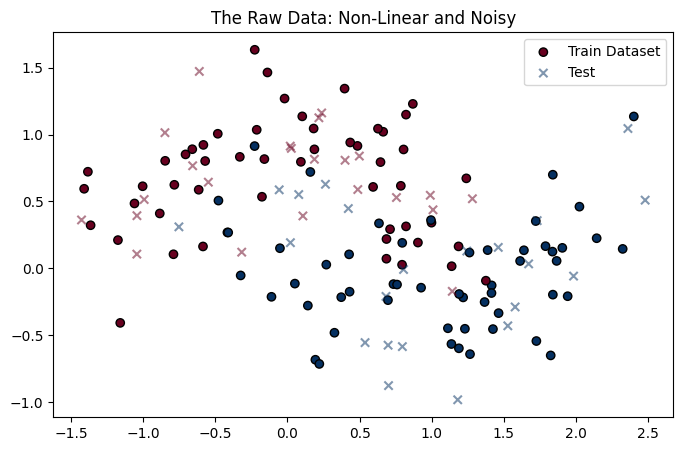

In [ ]:
x, y = make_moons(n_samples=150, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
plt.figure(figsize=(8, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdBu', edgecolors='k', label= "Train Dataset")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdBu', marker='x', alpha=0.5, label='Test')
plt.title("The Raw Data: Non-Linear and Noisy")
plt.legend()
plt.show()

In [ ]:
from sklearn.pipeline import make_pipeline
#  Create a pipeline with polynomial features and logistic regression without optimisation with a degree of 10
poly_features = PolynomialFeatures(degree=10)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

model = make_pipeline(StandardScaler(), LogisticRegression(solver='lbfgs', max_iter=10000))
model.fit(X_train_poly, y_train)
y_pred=model.predict(X_test_poly)
print("Accuracy:", accuracy_score(y_test, y_pred))



Accuracy: 0.8444444444444444


In [ ]:
# visualize the model with the decision boundary and degree=10
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    grid = np.c_[xx.ravel(), yy.ravel()]

    try:
        Z = model.predict(grid)
    except ValueError:
        Z = model.predict(poly_features.transform(grid))

    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='RdBu')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', s=100, cmap='RdBu')
    plt.title("Decision Boundary with Polynomial Features (degree=10)")
    plt.show()

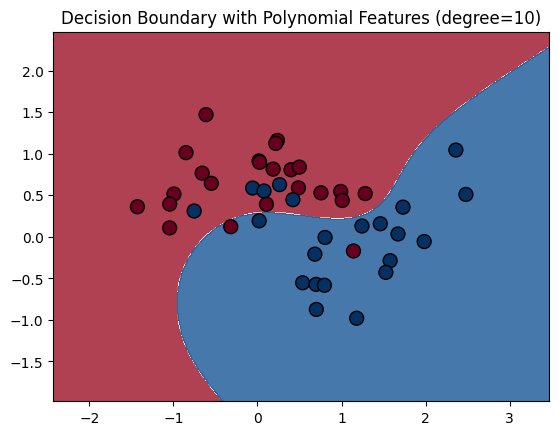

In [ ]:
plot_decision_boundary(model, X_test, y_test)

In [ ]:
# Create a pipeline with polynomial features and logistic regression with  L1 optimisation
model_l1 = make_pipeline(PolynomialFeatures(degree=10), StandardScaler(), LogisticRegression(penalty='l1', solver='liblinear', max_iter=10000))
model_l1.fit(X_train, y_train)
y_pred_l1=model_l1.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_l1))

Accuracy: 0.8444444444444444


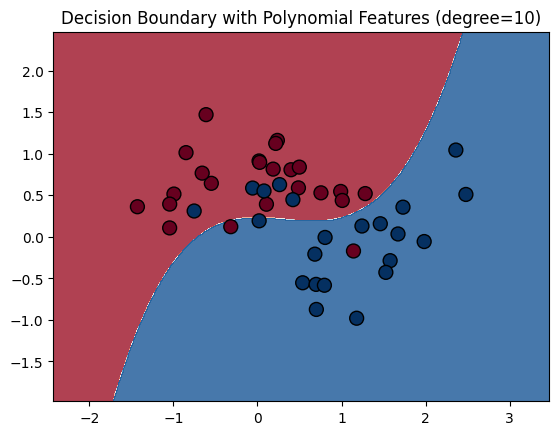

In [ ]:
plot_decision_boundary(model_l1, X_test, y_test)

In [ ]:
# Create a pipeline with polynomial features and logistic regression with L2 optimisation
model_l2 = make_pipeline(PolynomialFeatures(degree=10), StandardScaler(), LogisticRegression(penalty='l2', solver='lbfgs', max_iter=10000))
model_l2.fit(X_train, y_train)
y_pred_l2=model_l2.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_l2))

Accuracy: 0.8444444444444444


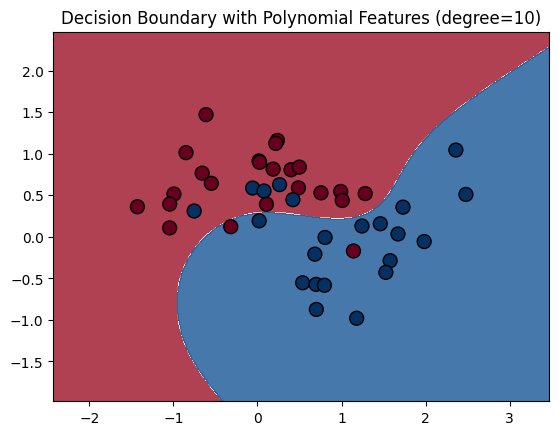

In [ ]:
plot_decision_boundary(model_l2, X_test, y_test)